# Investment Portfolio Analytics: Risk, Optimization & Backtesting

**Course:** Investment Management
**Author:** [Your Name]

## Objective
This notebook documents the complete analytical workflow used to build, evaluate, and backtest
an optimized multi-asset investment portfolio, applying Modern Portfolio Theory (Markowitz, 1952)
to real historical market data.

**Investment universe:** 8 assets across 5 sectors/asset classes (Technology, Financials,
Healthcare, Consumer Discretionary, Energy, Gold, Treasury Bonds) plus the S&P 500 (SPY) as
benchmark.

**Sample period:** August 2021 – August 2026 (5 years of daily data).

**Guiding question:** *Can a data-driven, mathematically optimized portfolio of common assets
meaningfully beat a passive S&P 500 investment on a risk-adjusted basis?*

All heavy computation is implemented in the reusable `src/` package; this notebook calls those
functions and narrates the results. See `README.md` for the full project writeup.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
from IPython.display import Image, display

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 20)

from src.config import DATA_PROCESSED_DIR, FIGURES_DIR, ASSET_INFO, PORTFOLIO_TICKERS


---
## 1. Data Collection & Cleaning

Raw daily OHLCV price data for all 9 tickers was sourced from WSJ Market Data (Aug 2021 – Aug
2026) and is stored in `data/raw/`. The `src.data_cleaning` module standardizes column names and
date formats, validates prices, and aligns all assets onto a common trading calendar (since
different tickers can have slightly different holiday conventions).


In [2]:
from src.data_cleaning import build_clean_dataset

close_prices, simple_returns, log_returns = build_clean_dataset()
print(f"\nFinal aligned panel: {close_prices.shape[0]} trading days x {close_prices.shape[1]} assets")
close_prices.head()


12:44:01 | INFO     | ============================================================


12:44:01 | INFO     | DATA CLEANING PIPELINE — START


12:44:01 | INFO     | ============================================================


12:44:01 | INFO     | Processing AAPL (Apple Inc.)


12:44:01 | INFO     |   -> 1257 rows | 2021-08-13 to 2026-08-12


...

12:44:01 | INFO     | ============================================================


12:44:01 | INFO     | DATA CLEANING PIPELINE — COMPLETE


12:44:01 | INFO     | ============================================================



Final aligned panel: 1254 trading days x 9 assets


,AAPL,MSFT,JPM,JNJ,AMZN,XOM,GLD,TLT,SPY
Date,,,,,,,,,
2021-08-13,149.10,292.85,159.98,176.25,164.6985,56.77,166.39,148.55,445.92
2021-08-16,151.12,294.60,158.93,177.84,164.9495,55.94,167.22,148.91,446.97
2021-08-17,150.19,293.08,157.01,179.47,162.0980,55.56,166.97,148.85,444.04
2021-08-18,146.36,290.73,155.58,177.19,160.0610,54.39,167.10,149.35,439.18
2021-08-19,146.70,296.77,154.28,178.57,159.3875,52.73,166.61,150.45,439.86


In [3]:
meta = pd.DataFrame(ASSET_INFO).T
meta.index.name = "Ticker"
meta


,name,sector
Ticker,,
AAPL,Apple Inc.,Technology
MSFT,Microsoft Corp.,Technology
JPM,JPMorgan Chase & Co.,Financials
JNJ,Johnson & Johnson,Healthcare
AMZN,Amazon.com Inc.,Consumer Discretionary
XOM,Exxon Mobil Corp.,Energy
GLD,SPDR Gold Shares,Commodities (Gold)
TLT,iShares 20+ Yr Treasury Bond ETF,Fixed Income
SPY,SPDR S&P 500 ETF Trust,Benchmark (Equity Index)


---
## 2. Exploratory Data Analysis

Before any modeling, we examine price behavior, return distributions, and — critically for
portfolio construction — the correlation structure across assets. Figures are generated by
`src.eda` and saved to `figures/`.

### 2.1 Growth of $100 Invested


12:44:02 | INFO     | ============================================================


12:44:02 | INFO     | STEP 3: EXPLORATORY DATA ANALYSIS — START


12:44:02 | INFO     | ============================================================


12:44:02 | INFO     | Loaded 1254 trading days x 9 assets


12:44:02 | INFO     | Saved 01_normalized_price_trends.png


...

12:44:04 | INFO     | Lowest pairwise correlation: -0.12 (see correlation_matrix.csv for full pair detail)


12:44:04 | INFO     | All figures saved to /home/claude/investment-portfolio-analysis/figures


12:44:04 | INFO     | ============================================================


12:44:04 | INFO     | STEP 3: EXPLORATORY DATA ANALYSIS — COMPLETE


12:44:04 | INFO     | ============================================================


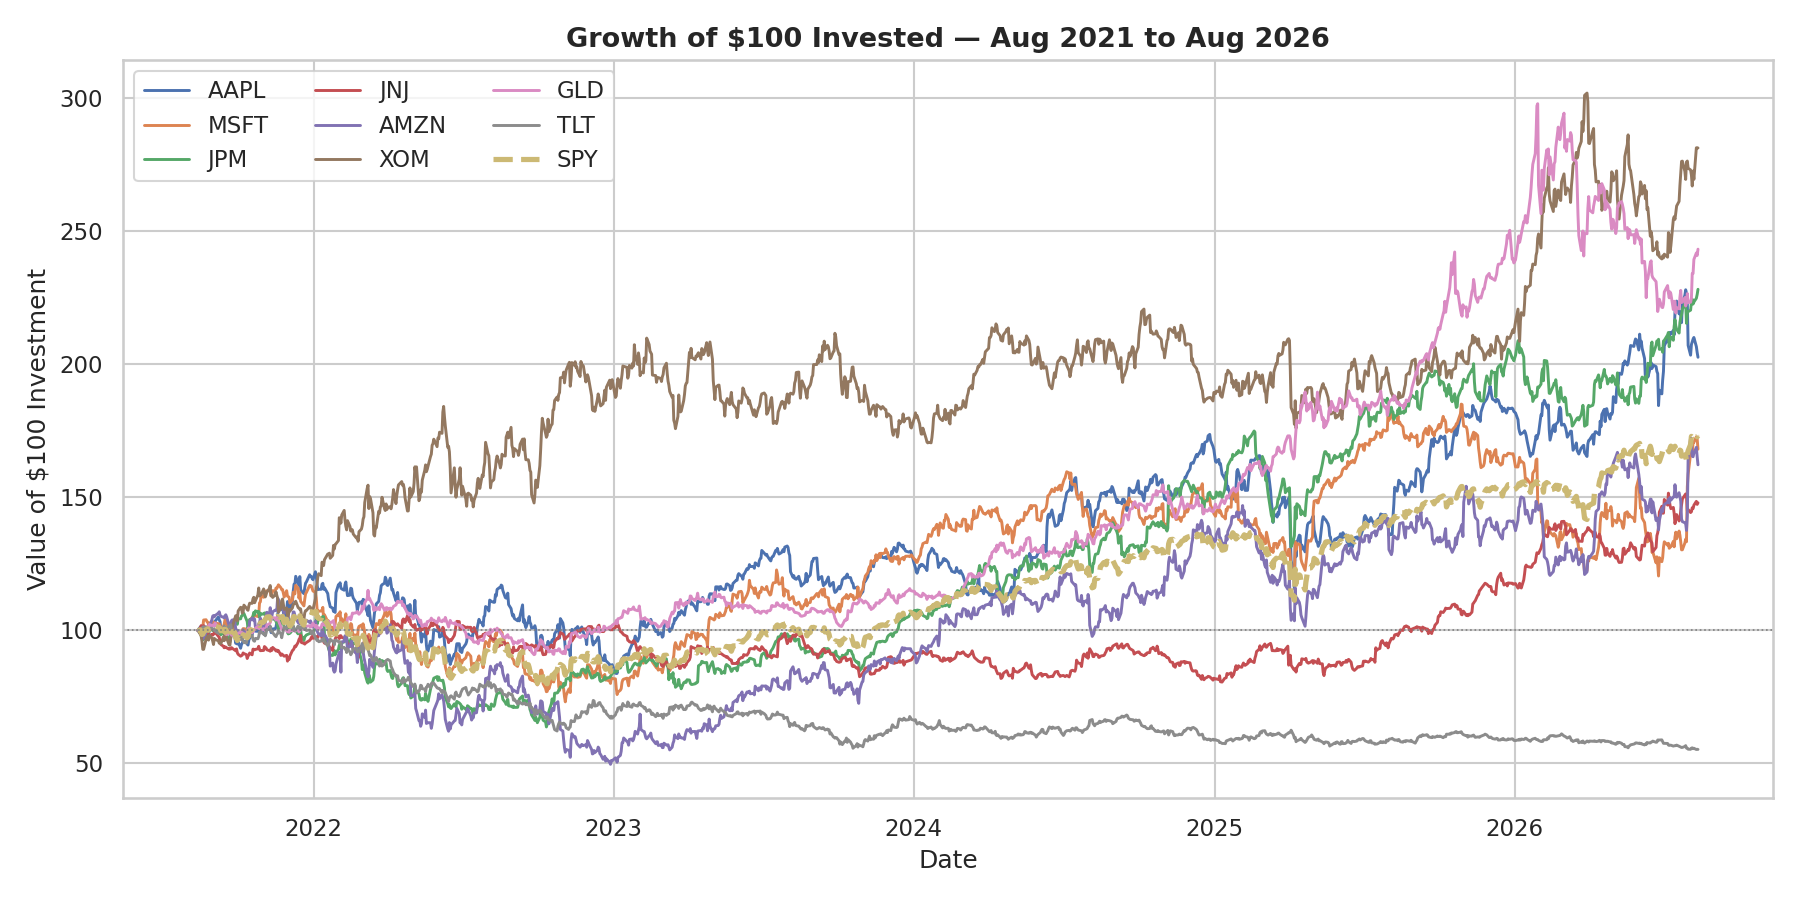

In [4]:
from src.eda import run_eda
run_eda()
display(Image(filename=str(FIGURES_DIR / "01_normalized_price_trends.png")))


**Observation:** XOM (Energy) and GLD (Gold) delivered the strongest cumulative growth over the
period, while TLT (long-duration Treasuries) declined steadily — a direct consequence of the
rising interest-rate environment during much of the sample.

### 2.2 Cumulative Returns vs. Benchmark


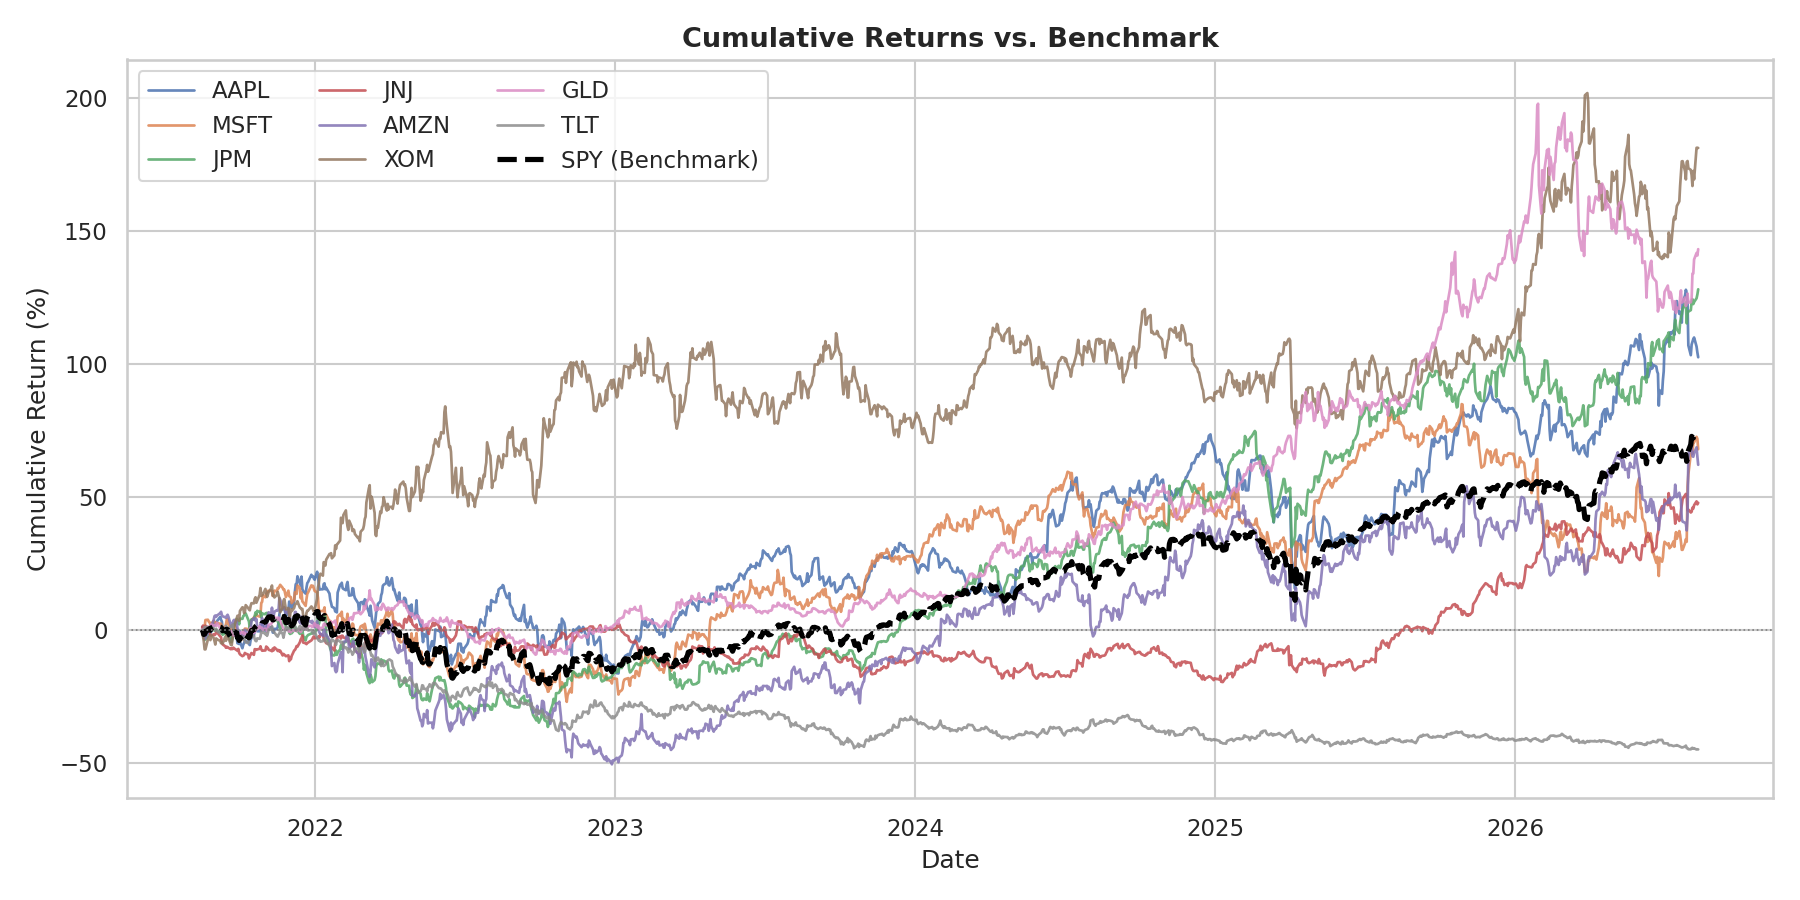

In [5]:
display(Image(filename=str(FIGURES_DIR / "02_cumulative_returns.png")))

### 2.3 Correlation Structure

This matrix is the single most important input to the diversification analysis in Section 4:
low or negative correlations are what create risk-reduction benefit in a portfolio.


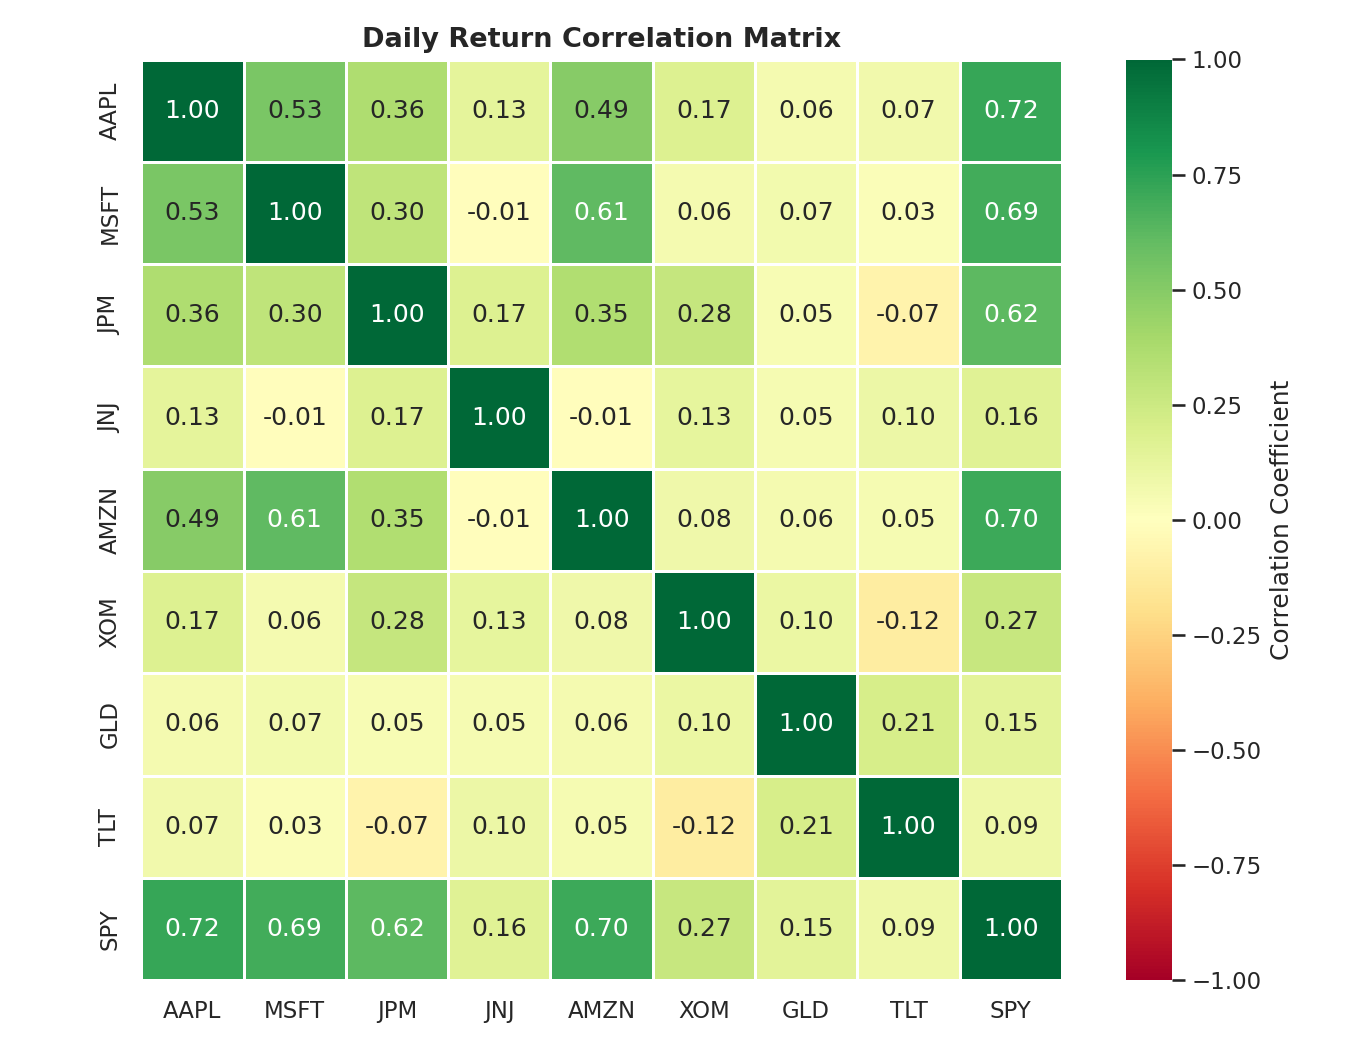

,AAPL,MSFT,JPM,JNJ,AMZN,XOM,GLD,TLT,SPY
AAPL,1.00,0.53,0.36,0.13,0.49,0.17,0.06,0.07,0.72
MSFT,0.53,1.00,0.30,-0.01,0.61,0.06,0.07,0.03,0.69
JPM,0.36,0.30,1.00,0.17,0.35,0.28,0.05,-0.07,0.62
JNJ,0.13,-0.01,0.17,1.00,-0.01,0.13,0.05,0.10,0.16
AMZN,0.49,0.61,0.35,-0.01,1.00,0.08,0.06,0.05,0.70
XOM,0.17,0.06,0.28,0.13,0.08,1.00,0.10,-0.12,0.27
GLD,0.06,0.07,0.05,0.05,0.06,0.10,1.00,0.21,0.15
TLT,0.07,0.03,-0.07,0.10,0.05,-0.12,0.21,1.00,0.09
SPY,0.72,0.69,0.62,0.16,0.70,0.27,0.15,0.09,1.00


In [6]:
display(Image(filename=str(FIGURES_DIR / "03_correlation_heatmap.png")))
corr = pd.read_csv(DATA_PROCESSED_DIR / "correlation_matrix.csv", index_col=0)
corr.round(2)


**Observation:** GLD and TLT show near-zero correlation with the equity holdings (0.05–0.21),
identifying them as the strongest diversification candidates — while the equities themselves are
moderately-to-highly correlated with each other and with SPY (0.36–0.72), as expected.

### 2.4 Return Distributions & Rolling Volatility


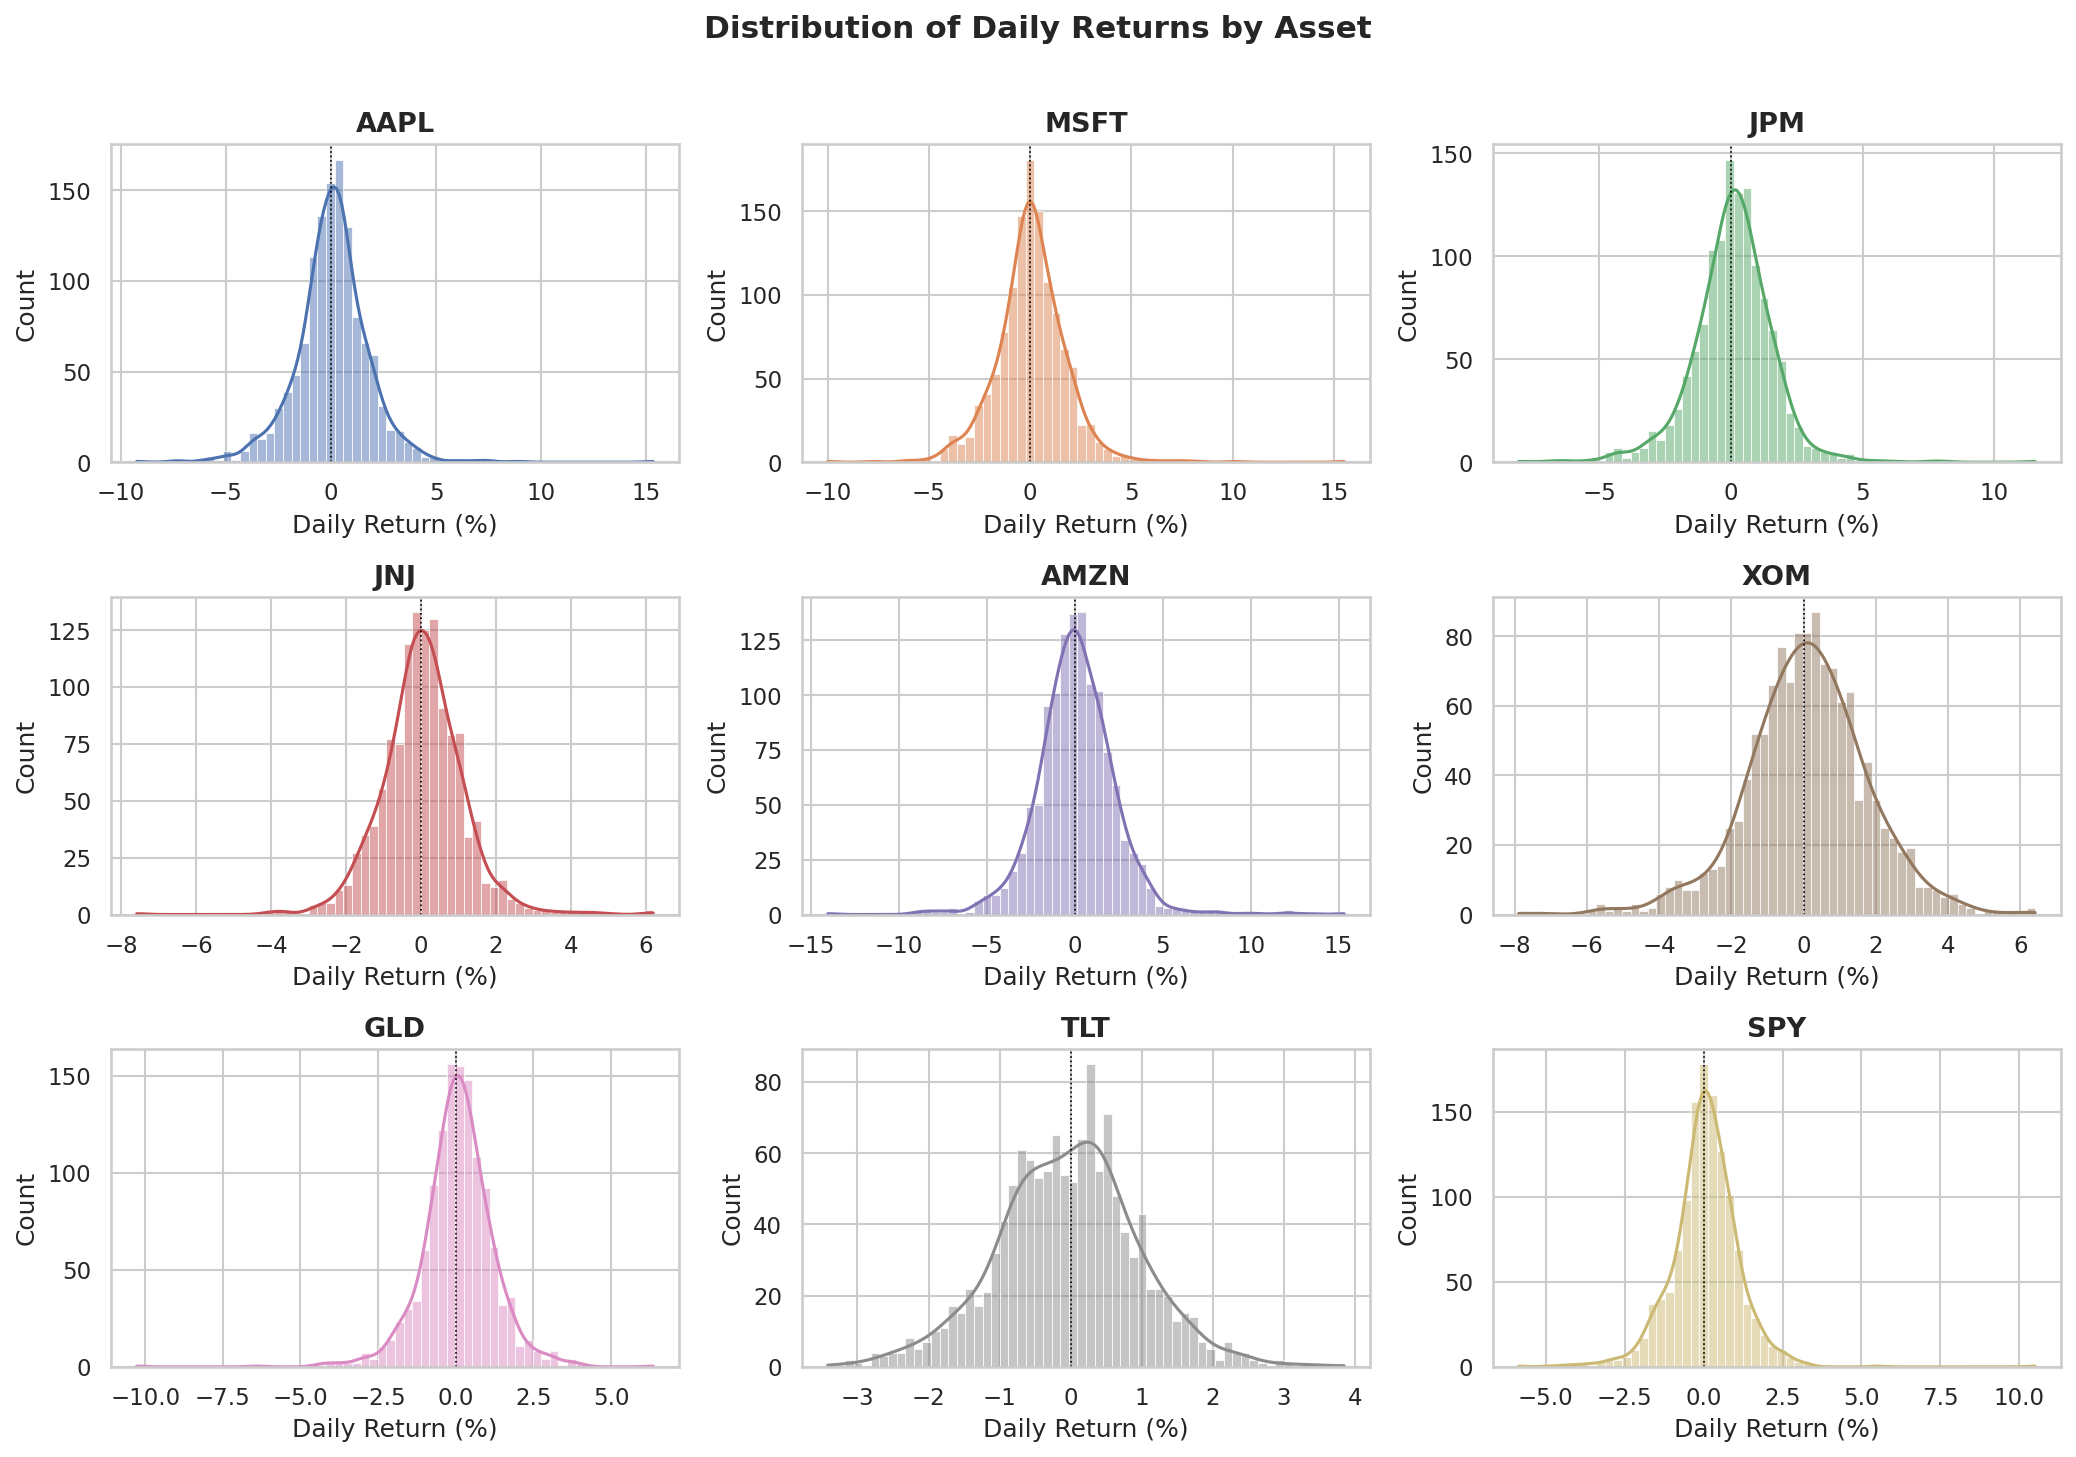

In [7]:
display(Image(filename=str(FIGURES_DIR / "04_return_distributions.png")))

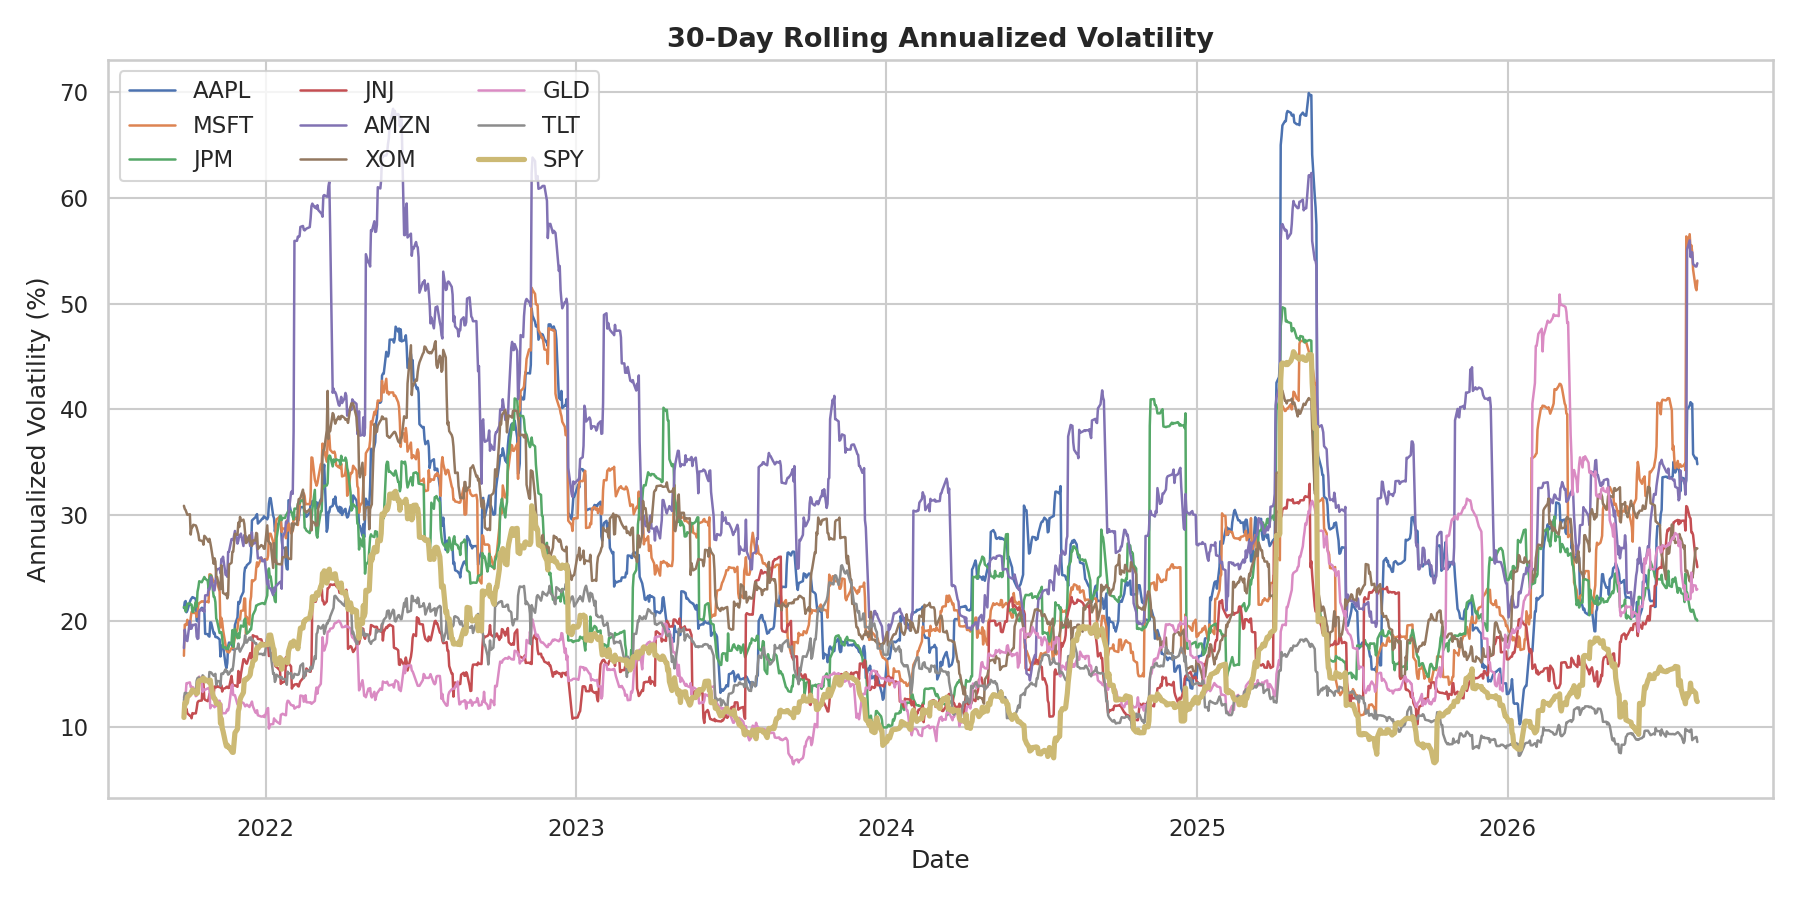

In [8]:
display(Image(filename=str(FIGURES_DIR / "05_rolling_volatility.png")))

**Observation:** Growth stocks (AAPL, MSFT, AMZN) show visibly fat-tailed return distributions,
meaning standard deviation alone understates their true tail risk — this motivates the use of
VaR/CVaR (not just volatility) in the next section. A clear market-wide volatility spike is visible
around mid-2025.


---
## 3. Risk & Return Metrics

We now compute the standard suite of investment-management risk/return metrics for every asset:
annualized return and volatility, Sharpe/Sortino/Calmar ratios, historical & parametric Value at
Risk (VaR), Conditional VaR (Expected Shortfall), and CAPM Beta/Alpha vs. the SPY benchmark.


In [9]:
from src.risk_metrics import run_risk_analysis

metrics = run_risk_analysis()
metrics


12:44:04 | INFO     | ============================================================


12:44:04 | INFO     | STEP 4: RISK & RETURN METRICS — START


12:44:04 | INFO     | ============================================================


12:44:04 | INFO     | Loaded returns for 9 assets over 1253 trading days


12:44:04 | INFO     | Saved metrics table -> risk_return_metrics.csv


...

12:44:05 | INFO     | Worst Max Drawdown:   AMZN (-55.7%)


12:44:05 | INFO     | ============================================================


12:44:05 | INFO     | STEP 4: RISK & RETURN METRICS — COMPLETE


12:44:05 | INFO     | ============================================================


,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%),"Historical VaR 95% (Daily, %)","Parametric VaR 95% (Daily, %)","CVaR 95% (Daily, %)",Beta (vs. SPY),"Jensen's Alpha (Annualized, %)"
AAPL,15.271,28.058,0.489,0.706,0.457,-33.434,-2.743,-2.835,-3.989,1.172,4.199
MSFT,11.018,28.156,0.355,0.534,0.293,-37.556,-2.696,-2.860,-3.819,1.125,0.835
JPM,18.056,24.496,0.620,0.864,0.444,-40.645,-2.421,-2.460,-3.592,0.879,8.049
JNJ,8.205,17.517,0.286,0.432,0.347,-23.628,-1.698,-1.778,-2.331,0.161,3.708
AMZN,10.228,36.400,0.328,0.492,0.184,-55.726,-3.331,-3.707,-5.003,1.484,-0.140
XOM,23.131,26.797,0.747,1.097,1.120,-20.651,-2.697,-2.680,-3.841,0.416,16.624
GLD,19.586,18.555,0.820,1.079,0.742,-26.405,-1.795,-1.845,-2.694,0.159,13.926
TLT,-11.240,15.720,-0.960,-1.510,-0.240,-46.835,-1.701,-1.671,-2.184,0.079,-15.730
SPY,11.685,17.254,0.472,0.654,0.461,-25.361,-1.671,-1.738,-2.467,1.000,0.000


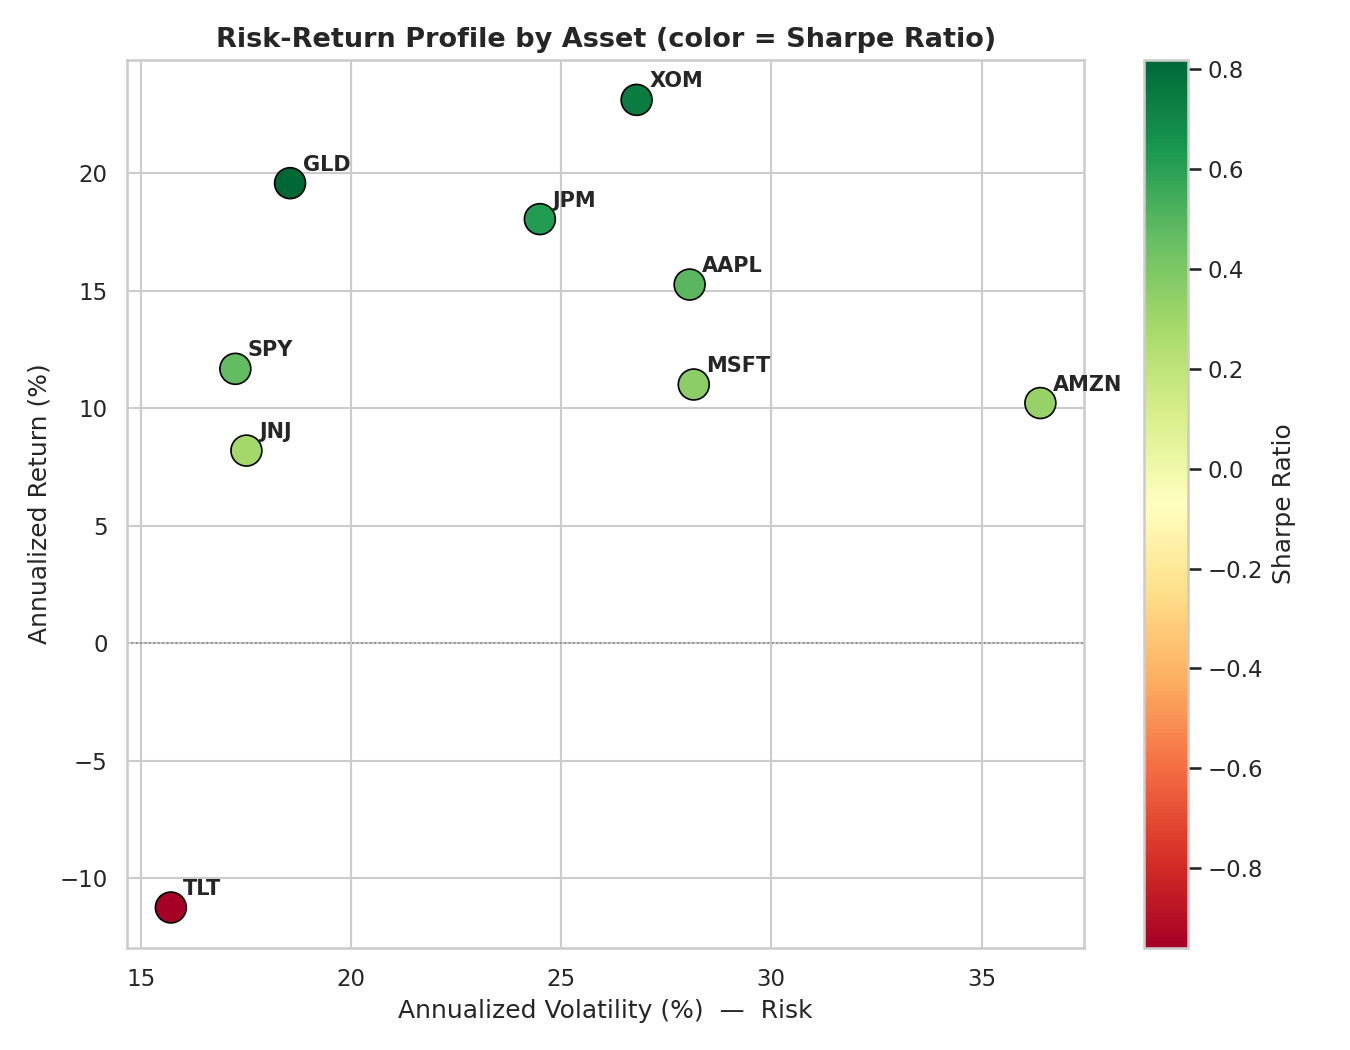

In [10]:
display(Image(filename=str(FIGURES_DIR / "06_risk_return_scatter.png")))

**Observation:** GLD (Sharpe 0.82) and XOM (Sharpe 0.75) were the top individual risk-adjusted
performers. TLT was the clear laggard (Sharpe −0.96) — both a low return *and* a losing bet in
absolute terms over this particular rate cycle.


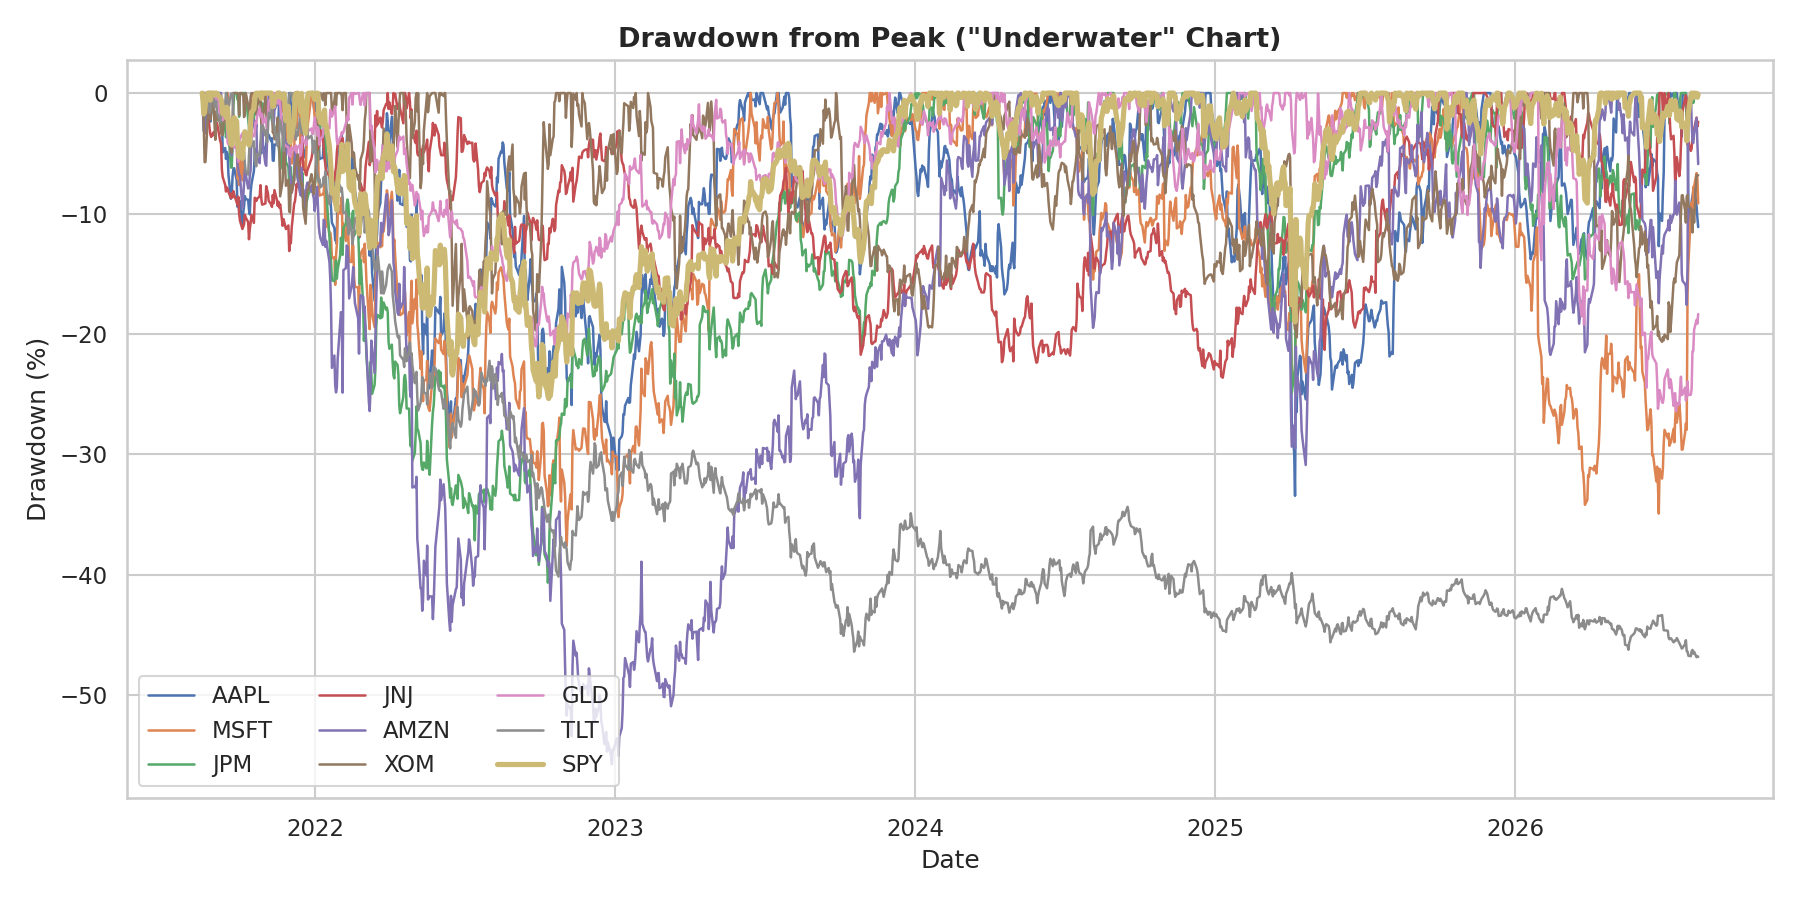

In [11]:
display(Image(filename=str(FIGURES_DIR / "07_drawdown_chart.png")))

---
## 4. Portfolio Optimization (Markowitz)

Using the annualized expected returns and covariance matrix estimated from daily log returns, we
solve for two classic portfolios via constrained optimization (SciPy SLSQP, long-only,
fully-invested):

- **Maximum Sharpe Ratio Portfolio** (the "tangency" portfolio)
- **Global Minimum Variance (GMV) Portfolio**

We also trace the full **Efficient Frontier** and validate it visually against a 15,000-portfolio
Monte Carlo simulation. The benchmark (SPY) is excluded from the optimizable universe since it
represents the passive comparison point, not a candidate holding.


In [12]:
from src.portfolio_optimization import run_portfolio_optimization

results = run_portfolio_optimization()

print("Max Sharpe Portfolio Weights:")
for ticker, w in sorted(results["max_sharpe_weights"].items(), key=lambda x: -x[1]):
    if w > 0.001:
        print(f"  {ticker}: {w:.1%}")

print("\nMin Variance Portfolio Weights:")
for ticker, w in sorted(results["min_var_weights"].items(), key=lambda x: -x[1]):
    if w > 0.001:
        print(f"  {ticker}: {w:.1%}")


12:44:05 | INFO     | ============================================================


12:44:05 | INFO     | STEP 5: PORTFOLIO OPTIMIZATION — START


12:44:05 | INFO     | ============================================================


12:44:05 | INFO     | Optimizing over 8 assets: ['AAPL', 'MSFT', 'JPM', 'JNJ', 'AMZN', 'XOM', 'GLD', 'TLT']


12:44:05 | INFO     | Solving for Maximum Sharpe Ratio portfolio...


...

12:44:08 | INFO     | Saved optimal_portfolio_weights.csv and optimal_portfolio_summary.csv


12:44:08 | INFO     | ============================================================


12:44:08 | INFO     | STEP 5: PORTFOLIO OPTIMIZATION — COMPLETE


12:44:08 | INFO     | ============================================================


Max Sharpe Portfolio Weights:
  GLD: 50.2%
  XOM: 23.1%
  JPM: 17.1%
  AAPL: 6.5%
  JNJ: 3.1%

Min Variance Portfolio Weights:
  TLT: 33.6%
  JNJ: 23.3%
  GLD: 17.1%
  XOM: 9.7%
  MSFT: 8.3%
  JPM: 8.0%


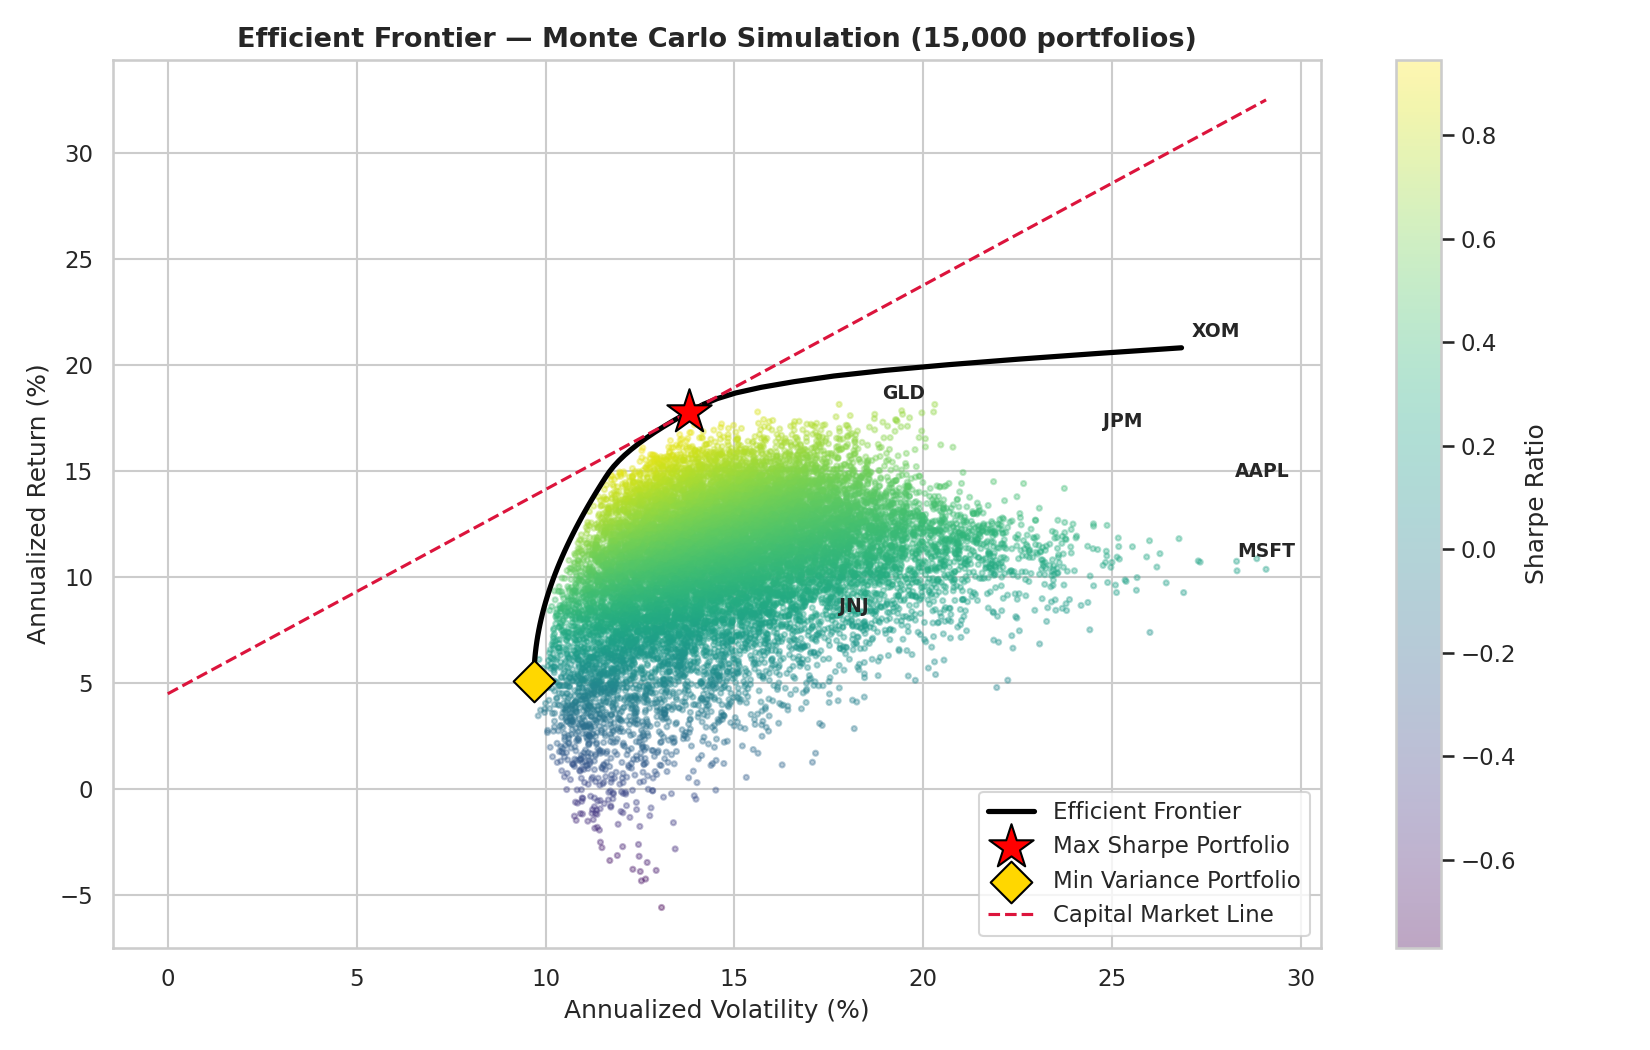

In [13]:
display(Image(filename=str(FIGURES_DIR / "08_efficient_frontier.png")))

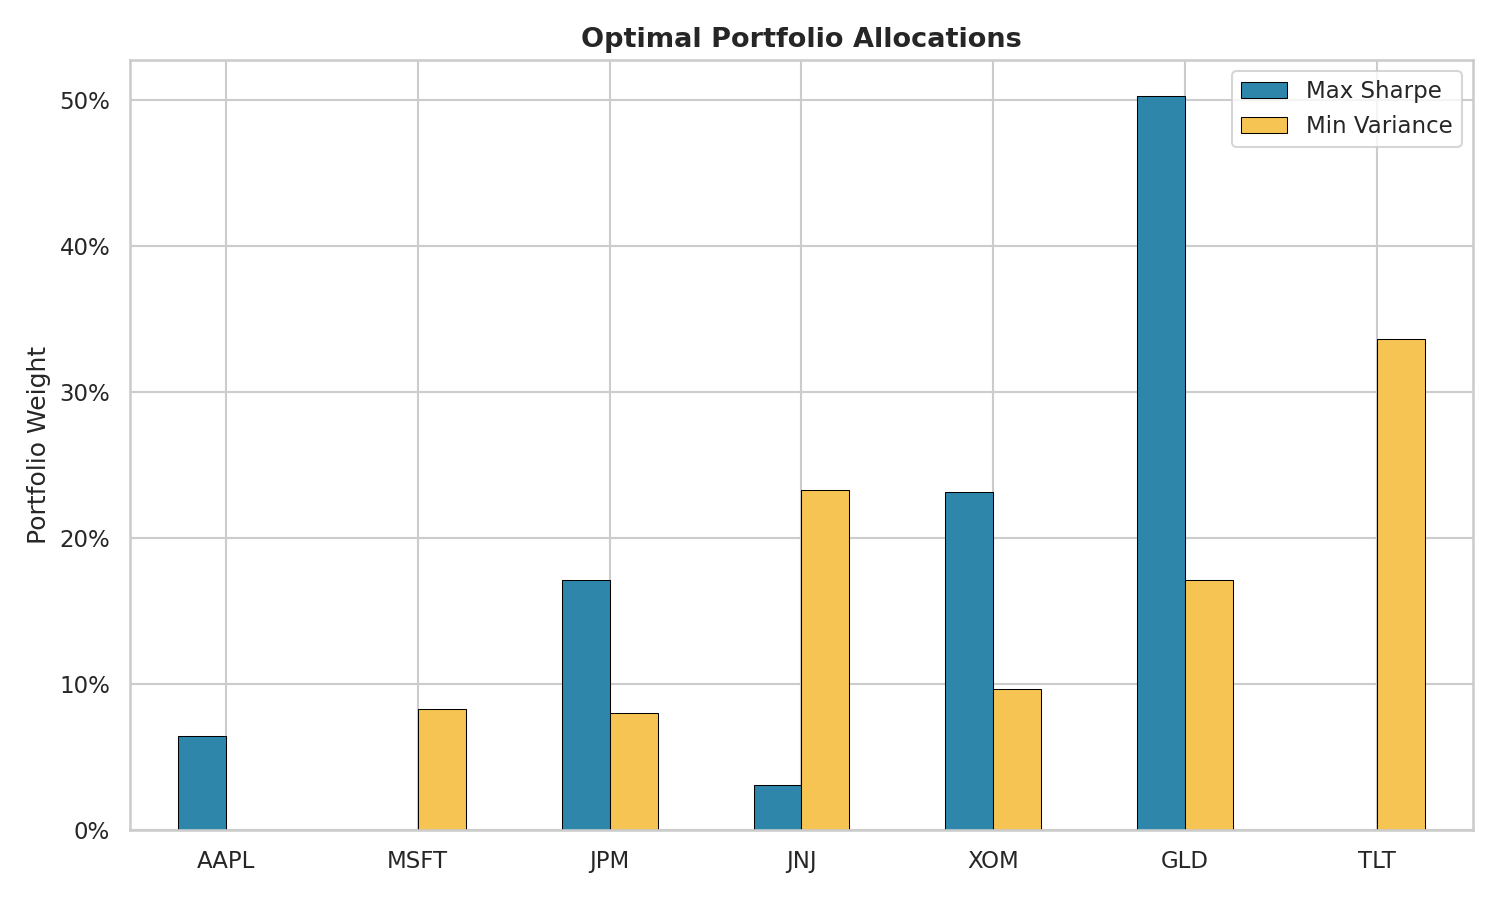

,Max Sharpe Weight,Min Variance Weight
AAPL,0.0647,0.0000
MSFT,0.0000,0.0827
JPM,0.1710,0.0801
JNJ,0.0308,0.2328
AMZN,0.0000,0.0000
XOM,0.2311,0.0970
GLD,0.5024,0.1715
TLT,0.0000,0.3360


In [14]:
display(Image(filename=str(FIGURES_DIR / "09_optimal_weights.png")))
weights = pd.read_csv(DATA_PROCESSED_DIR / "optimal_portfolio_weights.csv", index_col=0)
weights


**Observation:** The optimizer — with no sector heuristics imposed — arrived at a Max Sharpe
allocation of roughly 50% GLD, 23% XOM, 17% JPM, 7% AAPL, and 3% JNJ: effectively a
"growth-plus-defensive-hedge" structure that mirrors classic portfolio construction intuition,
discovered purely from the data.


---
## 5. Backtesting

Finally, we simulate how both optimal portfolios would have actually performed historically,
under two management approaches: **Buy & Hold** (weights set once and left to drift) and
**Quarterly Rebalancing** (weights reset to target every quarter) — compared against a Buy & Hold
position in SPY.


In [15]:
from src.backtesting import run_backtest

summary = run_backtest()
summary


12:44:08 | INFO     | ============================================================


12:44:08 | INFO     | STEP 6: BACKTESTING — START


12:44:08 | INFO     | ============================================================


12:44:08 | INFO     | Simulating Max Sharpe portfolio (Buy & Hold)...


12:44:08 | INFO     | Simulating Max Sharpe portfolio (Quarterly Rebalanced)...


...

12:44:08 | INFO     | Saved backtest_summary.csv


12:44:08 | INFO     | ============================================================


12:44:08 | INFO     | STEP 6: BACKTESTING — COMPLETE


12:44:08 | INFO     | ============================================================


,Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Total Return (%)
Max Sharpe — Buy & Hold,19.687,14.714,0.996,1.380,-15.381,144.206
Max Sharpe — Quarterly Rebalanced,21.265,13.967,1.136,1.581,-15.243,160.625
Min Variance — Buy & Hold,9.062,10.403,0.463,0.675,-15.394,53.877
Min Variance — Quarterly Rebalanced,6.828,9.733,0.275,0.417,-16.737,38.841
"SPY (Benchmark, Buy & Hold)",11.642,17.260,0.469,0.651,-25.361,72.828


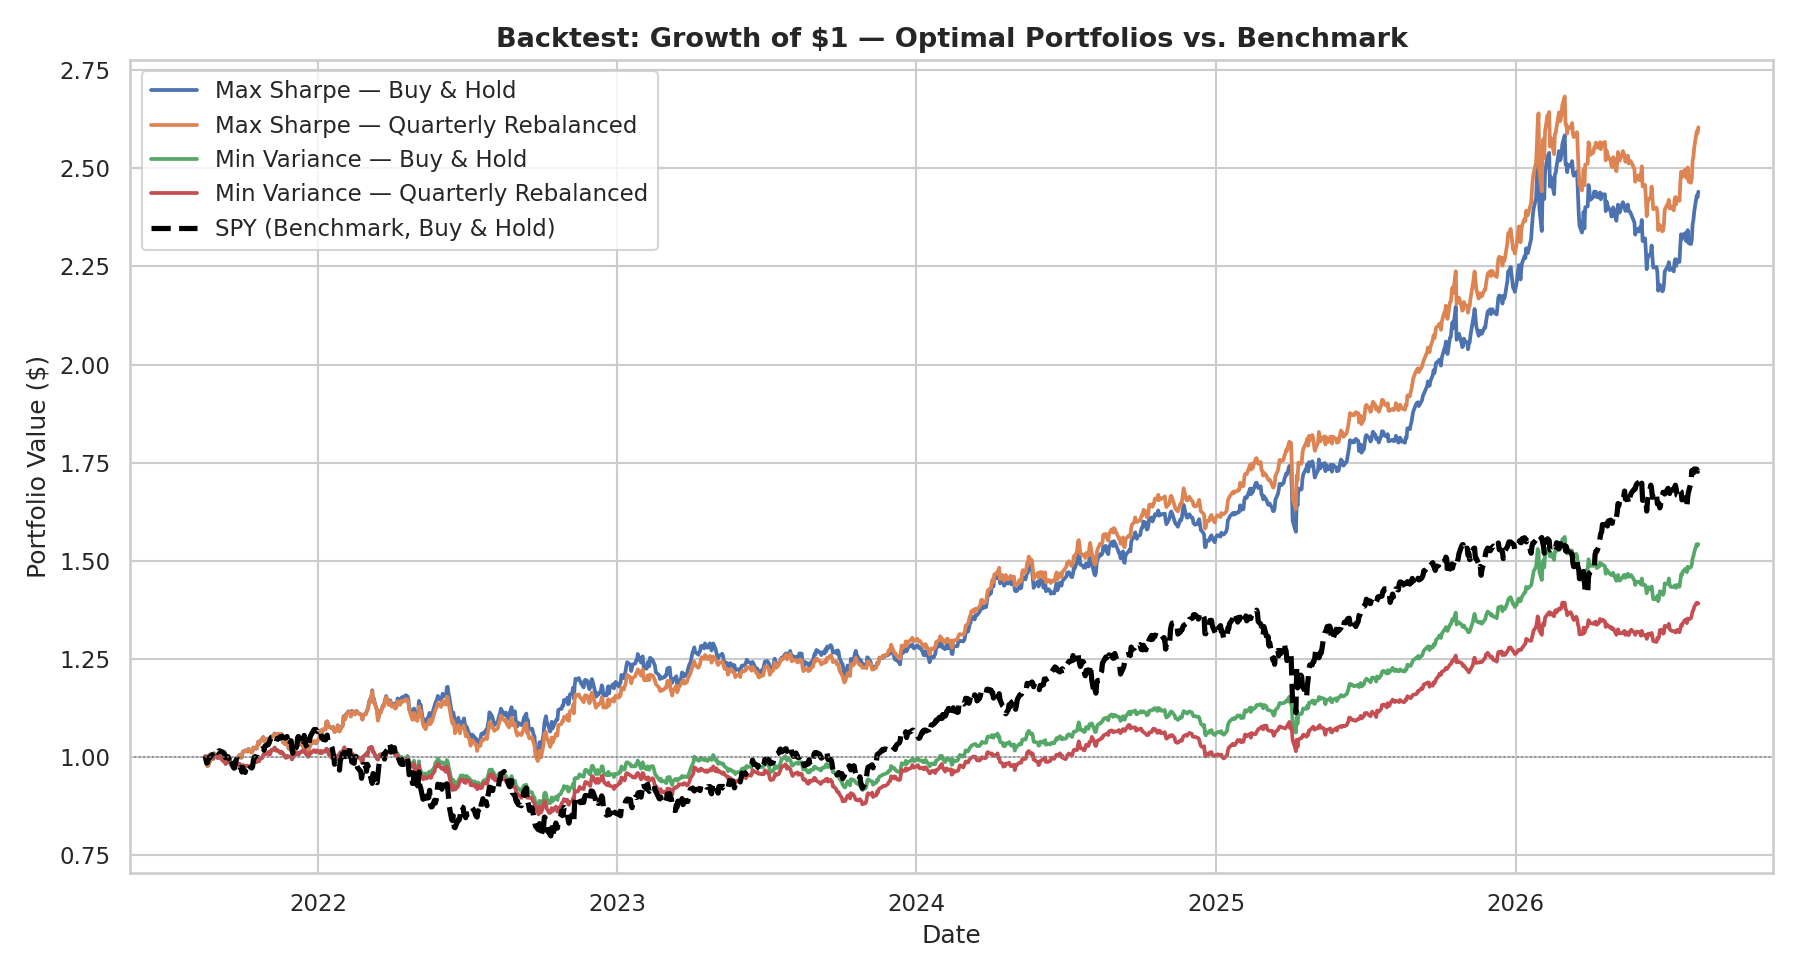

In [16]:
display(Image(filename=str(FIGURES_DIR / "10_backtest_comparison.png")))

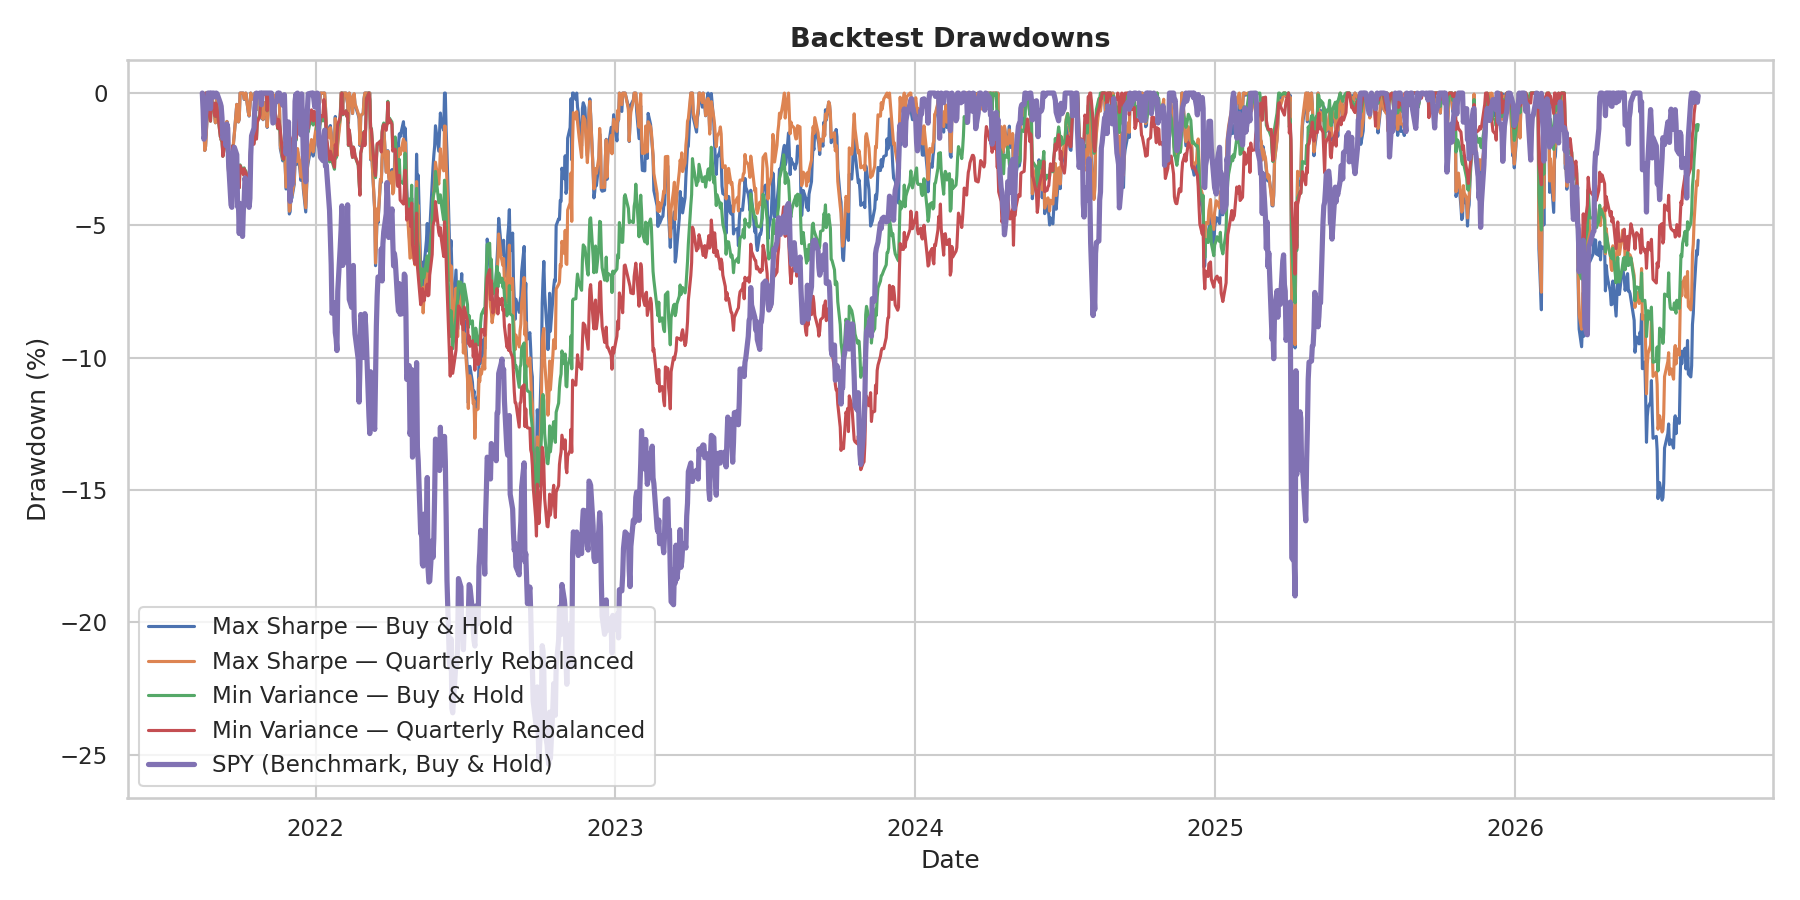

In [17]:
display(Image(filename=str(FIGURES_DIR / "11_backtest_drawdowns.png")))

**Observation:** Quarterly rebalancing *improved* the Max Sharpe portfolio (21.3% vs. 19.7%
annualized return) by systematically harvesting gains from outperforming assets, but *hurt* the
Minimum Variance portfolio (6.8% vs. 9.1%) — an interesting asymmetry suggesting the benefit of
rebalancing depends on the underlying return-generating process of the target allocation, not a
universal rule.


---
## 6. Conclusion

| Strategy | Annualized Return | Annualized Volatility | Sharpe Ratio | Max Drawdown |
|---|---:|---:|---:|---:|
| **Max Sharpe — Quarterly Rebalanced** | **21.3%** | 14.0% | **1.14** | -15.2% |
| Max Sharpe — Buy & Hold | 19.7% | 14.7% | 1.00 | -15.4% |
| Min Variance — Buy & Hold | 9.1% | 10.4% | 0.46 | -15.4% |
| Min Variance — Quarterly Rebalanced | 6.8% | 9.7% | 0.28 | -16.7% |
| **S&P 500 (SPY) — Benchmark** | 11.6% | 17.3% | 0.47 | -25.4% |

The Markowitz-optimized portfolio outperformed the passive S&P 500 benchmark on **both** return
and risk over the 5-year sample — nearly double the annualized return, with lower volatility and a
substantially shallower maximum drawdown. This is a direct, empirical demonstration of the
diversification benefit that Modern Portfolio Theory predicts.

### Limitations
- All metrics are historical (2021–2026) and not a guarantee of future performance.
- The backtest does not model transaction costs or taxes, which would reduce realized returns,
  especially under quarterly rebalancing.
- The optimizer is long-only and static; it does not consider short positions, leverage, or a
  dynamically evolving investable universe.

### Future Work
- Factor-based risk decomposition (Fama-French 3/5-factor model)
- Rolling/expanding-window backtests to test parameter stability out-of-sample
- Black-Litterman optimization to incorporate subjective market views

*See the interactive Streamlit dashboard (`dashboard/app.py`) for an explorable version of this
entire analysis.*
